# R3-Tool_HW



## 非程式題

請前往 https://mcp.so/ ，選擇一個 MCP Server，並回答以下問題：

1. 該 MCP Server 的名稱為何？
2. 它提供了哪些主要功能？
3. 你認為這些功能可以應用於哪些實際場景或解決哪些問題？

## 程式題
### baseline

使用 LangChain 的 Agent，註冊三個工具（查天氣、查時間、查匯率），讓 Agent 根據輸入自動選擇正確的工具來回答問題。

In [6]:
import os, getpass

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.prebuilt import create_react_agent
from langchain_google_genai import ChatGoogleGenerativeAI
import json

In [7]:
@tool
def get_weather(location: str) -> str:
    """查詢指定地點的天氣資訊"""
    return f"{location} 今天天氣晴，溫度約 25°C。"

@tool
def get_time(location: str) -> str:
    """查詢指定地點的當前時間"""
    return f"{location} 現在時間是下午 3:00。"

@tool
def get_exchange_rate(currency: str) -> str:
    """查詢指定貨幣對台幣的匯率"""
    if currency.upper() == "USD":
        return "1 USD = 31.25 TWD"
    elif currency.upper() == "JPY":
        return "1 JPY = 0.22 TWD"
    else:
        return f"{currency.upper()} 匯率資料暫無法提供"


In [8]:
# LLM
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("GOOGLE_API_KEY")
model_name = "gemini-2.5-flash-preview-05-20"
llm = ChatGoogleGenerativeAI(model=model_name)

In [4]:
tools = [get_weather, get_time, get_exchange_rate]
agent = create_react_agent(llm, tools)

In [5]:
# 天氣
response = agent.invoke({"messages": [HumanMessage(content="台北今天天氣如何？")]})
print(response["messages"][-1].content)

台北今天天氣晴，溫度約 25°C。


In [6]:
# 時間
response = agent.invoke({"messages": [HumanMessage(content="請問東京現在幾點？")]})
print(response["messages"][-1].content)

東京現在時間是下午 3:00。


In [7]:
# 匯率
response = agent.invoke({"messages": [HumanMessage(content="美金對台幣的匯率是多少？")]})
print(response["messages"][-1].content)


美金匯率資料暫無法提供。


## Advanced
使用LangGraph建立一個流程，由llm判斷問題是否與哆啦A夢道具相關，若有則使用RAG在資料庫裡找尋相關資料，若無則由模型自行回答問題。

Hint:參考流程圖

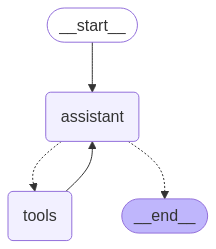

In [18]:
from typing import TypedDict, Annotated, Sequence
import operator
import os, getpass
from IPython.display import Image, display


from langgraph.graph import StateGraph, END
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.vectorstores import FAISS
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage


In [7]:
# LLM
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("GOOGLE_API_KEY")
model_name = "gemini-2.5-flash-preview-05-20"
llm = ChatGoogleGenerativeAI(model=model_name)

In [8]:
docs_text = """
道具名稱	功能
引路天使	它可以告訴你最好的路，不至於在路上出意外。
雲朵凝固瓦斯	使用這個瓦斯的話，雲會凝固，變得可以奔走在雲上。
交換繩	兩人同時握住繩索的話，心還是一樣，但身體替換。
室內旅行機	可以顯示出各種地點的立體影像，但室內面積並不會隨之更動。會讓自己的家有旅行的味道。
落難神明	是一個難看老機器人。不過，幫助他的話，可以滿足3個請求。
南北極徽章	只要將自己與另外一個人貼上寫有「Ｎ」或「Ｓ」的徽章，就會變的像磁鐵一樣，同極相斥，異極相吸。
間諜工具組合	能用監視器看間諜人偶的「麥克風」和「」偵察的影像。
聲音糖果	只要利用這個錄製聲音，再給別人吃下去以後， 就可以得到被錄製聲音的特徵。
進化退化放射線槍	被這光照射到，動物就可以進化(或是退化)。
算了算了棒	用這個棒子將正在生氣的人的嘴巴堵住，並說「算了，算了」，那人氣就消了。
助興樂團	這兩個道具都是人型玩偶，都會播放音樂，讓氣氛變好；不同的是，只要讓小型插秧姑娘唱歌，就可以快速地完成插秧。
四次元口袋	哆啦A夢的道具都是放在這裡面的。四次元空間是個沒有大小的空間，要多大有多大。
美食桌巾	它可以幫你做出好吃的料理。無論甚麼料理都可以變出來。
愛神之箭	被箭射中的人，會對射箭的人產生好感。
感動麥克風	使用這個麥克風，發出的聲音就會讓人感動不已。
桃太郎丸子	讓動物吃下，他會對你言聽計從。
樵夫之泉	把東西丟到這個泉裡，女神就會出現。如果你說了實話，他就會給你一個更好、更新的東西。
更衣照相機	選擇合適的衣服，拍攝一下馬上就能穿在身上。
穿透環	可以穿過任何障礙。
如果電話亭	「如果這個世界是……」只要這樣對著話筒說話，就可以創造出你所說出的世界。但是當取消時，世界將會變成「平行世界」，雙方沒有瓜葛。
翻譯蒟蒻	吃了這個蒟蒻，任何人說的任何話，我們都可以聽懂、而且可以溝通。
縮小燈	被光照射到，東西會變小。
記憶麵包	只要吃下這個吐司，就能非常容易的記住事前寫在吐司上的事物。
時光布	包了的東西既可以變新，也可以變舊。
竹蜻蜓	是最常被哆啦A夢使用的道具！只要把它放置在身體任何部分，就可依自己意思在天空中翱翔。內藏超小型電池，可時速 80 公里連續飛行 8 小時。若是間斷飛行，還可撐更久！
時光機	除了時間移動之外，它也可以用來空間與空間間的互相移動。
任意門	只要心中想著想去的地點，電腦就會傳達並歪曲所在地與目的地間的空間而將兩地靠攏，跨過門就可以到達。但是不能去距離十光年以上的行星，或者是電腦地圖上沒有的地區。是很常用的道具，使用率位列第三，僅次於竹蜻蜓、時光機。
"""

In [9]:
def create_rag_system():
    """使用 Gemini Embeddings 建立 RAG 向量資料庫"""
    lines = docs_text.strip().split('\n')[1:] 
    documents = []
    for line in lines:
        if '\t' in line:
            name, desc = line.split('\t', 1)
            content = f"道具名稱：{name}\n功能：{desc}"
            documents.append(Document(page_content=content, metadata={"tool_name": name}))

    # Gemini Embeddings
    embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
    
    # FAISS vectorstore
    vectorstore = FAISS.from_documents(documents, embeddings)
    return vectorstore

vectorstore = create_rag_system()
retriever = vectorstore.as_retriever(k=3)

In [16]:
@tool
def get_weather(location: str) -> str:
    """查詢指定地點的天氣資訊"""
    print("---正在使用天氣搜尋工具---")
    return f"{location} 今天天氣晴，溫度約 25°C。"

@tool
def get_time(location: str) -> str:
    """查詢指定地點的當前時間"""
    print("---正在使用時間搜尋工具---")
    return f"{location} 現在時間是下午 3:00。"

@tool
def get_exchange_rate(currency: str) -> str:
    """查詢指定貨幣對台幣的匯率"""
    print("---正在使用匯率搜尋工具---")
    if currency.upper() == "USD":
        return "1 USD = 31.25 TWD"
    elif currency.upper() == "JPY":
        return "1 JPY = 0.22 TWD"
    else:
        return f"{currency.upper()} 匯率資料暫無法提供"
@tool
def doraemon_tool_search(question: str) -> str:
    """當問題與哆啦A夢的道具有關時，使用此工具來查詢相關資訊。"""
    print("---正在使用哆啦A夢道具搜尋工具---")
    
    # 1. 使用 retriever 進行 RAG 搜尋
    docs = retriever.invoke(question)
    rag_result = "\n\n".join([doc.page_content for doc in docs])
    
    # 2. 準備 Prompt 並呼叫 LLM 生成回答
    prompt = f"""
    請基於以下提供的哆啦A夢道具資訊來回答使用者的問題。

    [提供的道具資訊]
    {rag_result}

    [使用者的問題]
    {question}
    """
    response = llm.invoke([HumanMessage(content=prompt)])
    
    return response.content

advanced_tools = [get_weather, get_time, get_exchange_rate, doraemon_tool_search]
llm_with_tools = llm.bind_tools(advanced_tools)
tool_map = {tool.name: tool for tool in advanced_tools}

In [20]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [17]:
def call_agent(state):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def call_tools_manual(state):
    # Agent 的最後一則訊息必定是工具呼叫指令
    last_message = state['messages'][-1]
    tool_calls = last_message.tool_calls
    
    # 用來存放每個工具執行的結果
    tool_messages = []
    
    # 遍歷所有工具呼叫指令
    for call in tool_calls:
        if tool_to_call := tool_map.get(call['name']):
            observation = tool_to_call.invoke(call['args'])
            tool_messages.append(
                ToolMessage(
                    content=str(observation), 
                    tool_call_id=call['id']
                )
            )
        else:
            tool_messages.append(
                ToolMessage(
                    content=f"Error: Tool '{call['name']}' not found.",
                    tool_call_id=call['id']
                )
            )
    return {"messages": tool_messages}

def should_continue(state):
    last_message = state['messages'][-1]
    # 如果 Agent 的回應中沒有包含工具呼叫，代表它認為可以結束了
    if not last_message.tool_calls:
        return "end"
    # 否則，就繼續去執行工具
    else:
        return "continue"

In [24]:
workflow = StateGraph(AgentState)

workflow.add_node("agent", call_agent)
workflow.add_node("tools", call_tools_manual)

workflow.set_entry_point("agent")

workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    },
)

workflow.add_edge("tools", "agent")

agent = workflow.compile()

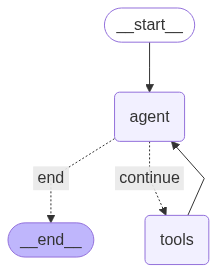

In [29]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [25]:
# 天氣
response = agent.invoke({"messages": [HumanMessage(content="台北今天天氣如何？")]})
print(response["messages"][-1].content)

---正在使用天氣搜尋工具---
台北今天天氣晴，溫度約 25°C。


In [26]:
# 時間
response = agent.invoke({"messages": [HumanMessage(content="請問東京現在幾點？")]})
print(response["messages"][-1].content)

---正在使用時間搜尋工具---
東京現在時間是下午 3:00。


In [27]:
# 匯率
response = agent.invoke({"messages": [HumanMessage(content="美金對台幣的匯率是多少？")]})
print(response["messages"][-1].content)

---正在使用匯率搜尋工具---
美金匯率資料目前無法提供。


In [28]:
# 多拉A夢
response = agent.invoke({"messages": [HumanMessage(content="任意門是什麼？")]})
print(response["messages"][-1].content)

---正在使用哆啦A夢道具搜尋工具---
任意門是哆啦A夢眾多道具中，最廣為人知且出場率極高的一個，也是許多人夢寐以求的道具。

**外觀特徵：** 通常是一扇粉紅色的門，可以獨立擺放。

**功能：** 只要打開門，並在心中或口中說出想去的地方，無論是隔壁房間、朋友家、學校、遙遠的城市、國外，甚至是地球的另一端，都能立刻抵達。它大大縮短了移動的時間和距離，是實現「瞬間移動」的交通工具。

**使用方式：** 通常只要直接打開門，並設定好目的地即可。

**限制：** 在某些特殊情況下（例如目的地太遠、不存在、或在不同次元、甚至是在宇宙中但沒有座標），也可能會有一些限制，無法順利抵達。

總體來說，任意門是實現「想去哪就去哪」的夢幻道具！
